In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# โหลดข้อมูล
df = pd.read_csv('data.csv')
print('โหลดข้อมูลสำเร็จ')
print('จำนวนแถวและคอลัมน์ (Shape):', df.shape)
display(df.head())

โหลดข้อมูลสำเร็จ
จำนวนแถวและคอลัมน์ (Shape): (500, 2)


,Weight,Height
0,67.062924,176.086355
1,68.804094,178.388669
2,60.930863,170.284496
3,59.733843,168.691992
4,65.431230,173.763679


In [2]:
print('Shape:', df.shape)
print('\nInfo:')
df.info()
print('\nDescribe:')
display(df.describe(include='all'))
print('\nMissing Values:')
display(df.isnull().sum())
print('\nจำนวน Missing ทั้งหมด:', int(df.isnull().sum().sum()))

Shape: (500, 2)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  500 non-null    float64
 1   Height  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB

Describe:


,Weight,Height
count,500.000000,500.000000
mean,61.270240,169.515781
std,5.196976,4.805095
min,50.433644,160.182164
25%,57.772791,166.607599
50%,61.961518,169.726252
75%,65.439332,172.837284
max,70.700456,178.894770



Missing Values:


Weight    0
Height    0
dtype: int64


จำนวน Missing ทั้งหมด: 0


In [3]:
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            mode_values = df_clean[col].mode(dropna=True)
            if not mode_values.empty:
                df_clean[col] = df_clean[col].fillna(mode_values.iloc[0])

print('Missing Values ก่อนจัดการ:')
display(df.isnull().sum())
print('Missing Values หลังจัดการ:')
display(df_clean.isnull().sum())

Missing Values ก่อนจัดการ:


Weight    0
Height    0
dtype: int64

Missing Values หลังจัดการ:


Weight    0
Height    0
dtype: int64

In [4]:
df_final = df_clean.copy()
numeric_cols = df_final.select_dtypes(include=np.number).columns.tolist()
outlier_summary = []

for col in numeric_cols:
    q1 = df_final[col].quantile(0.25)
    q3 = df_final[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df_final[col] < lower) | (df_final[col] > upper)).sum())
    outlier_summary.append({'Column': col, 'Lower Bound': lower, 'Upper Bound': upper, 'Outliers Found': count})
    if iqr > 0:
        df_final[col] = df_final[col].clip(lower=lower, upper=upper)

print('สรุป Outliers ก่อนจัดการ:')
display(pd.DataFrame(outlier_summary))
print('จำนวนแถวก่อน/หลังจัดการ:', len(df_clean), '/', len(df_final))

สรุป Outliers ก่อนจัดการ:


,Column,Lower Bound,Upper Bound,Outliers Found
0,Weight,46.272980,76.939143,0
1,Height,157.263072,182.181811,0


จำนวนแถวก่อน/หลังจัดการ: 500 / 500


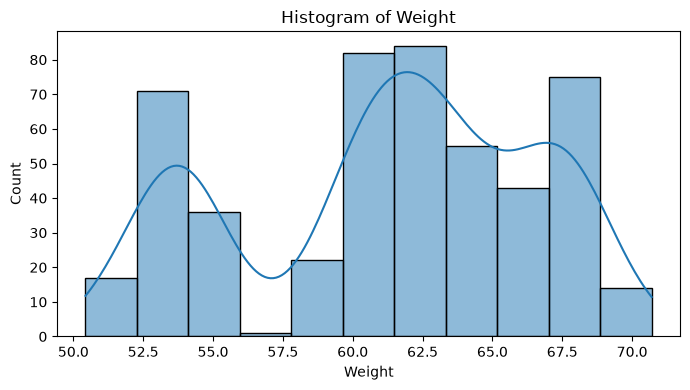

In [5]:
# รูปที่ 1: Histogram ของ Weight
plt.figure(figsize=(7, 4))
sns.histplot(data=df_final, x='Weight', kde=True)
plt.title('Histogram of Weight')
plt.tight_layout()
plt.show()

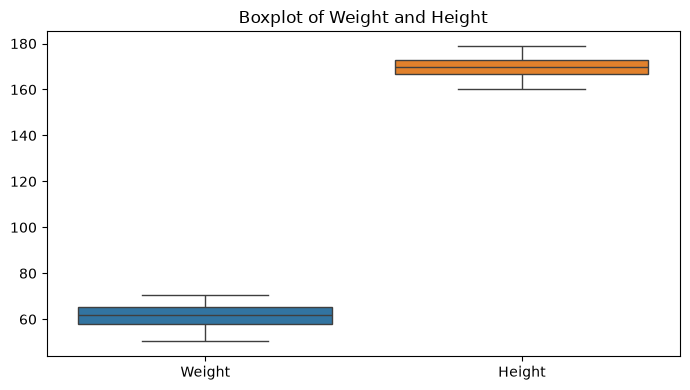

In [6]:
# รูปที่ 2: Boxplot ของ Weight และ Height
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_final[['Weight', 'Height']])
plt.title('Boxplot of Weight and Height')
plt.tight_layout()
plt.show()

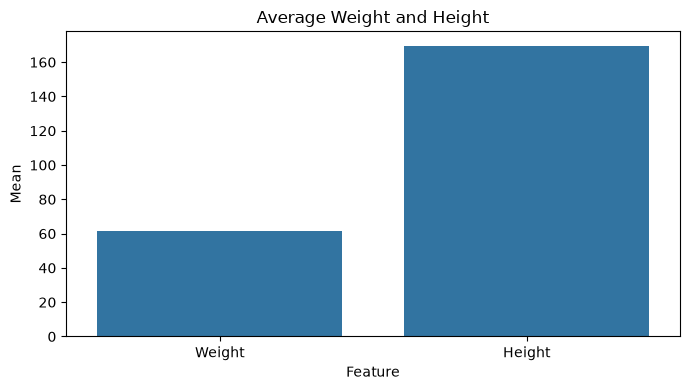

In [7]:
# รูปที่ 3: Bar Chart ค่าเฉลี่ย Weight และ Height
means = df_final[['Weight', 'Height']].mean().rename_axis('Feature').reset_index(name='Mean')
plt.figure(figsize=(7, 4))
sns.barplot(data=means, x='Feature', y='Mean')
plt.title('Average Weight and Height')
plt.tight_layout()
plt.show()

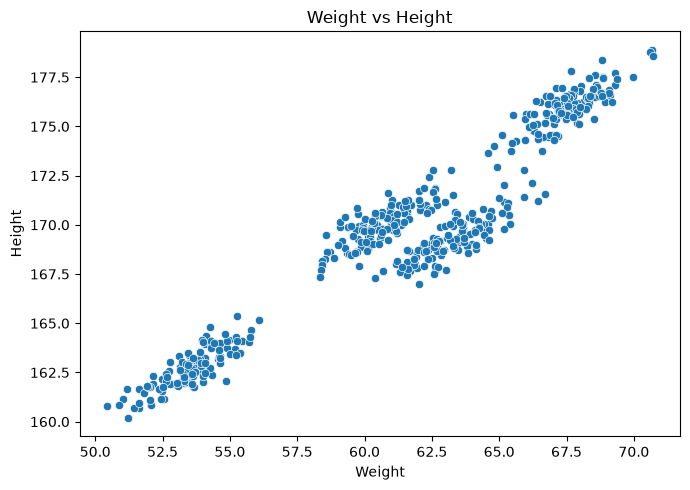

In [8]:
# รูปที่ 4: Scatter Plot ระหว่าง Weight และ Height
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_final, x='Weight', y='Height')
plt.title('Weight vs Height')
plt.tight_layout()
plt.show()

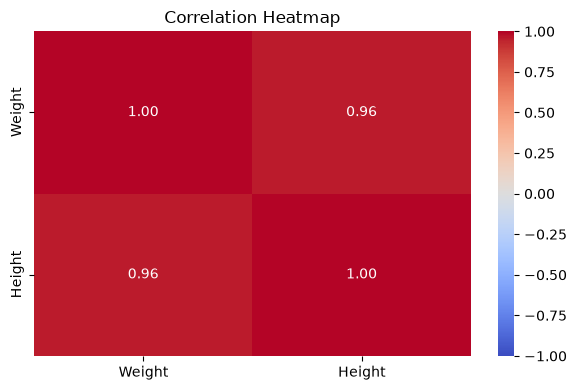

In [9]:
# รูปที่ 5: Heatmap ความสัมพันธ์ระหว่างตัวแปร
plt.figure(figsize=(6, 4))
corr = df_final[['Weight', 'Height']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [10]:
df_final.to_csv('data_cleaned.csv', index=False)
print('บันทึกข้อมูลที่ทำความสะอาดแล้วเป็น data_cleaned.csv เรียบร้อย')
print('Shape หลังทำความสะอาด:', df_final.shape)
display(df_final.describe())

บันทึกข้อมูลที่ทำความสะอาดแล้วเป็น data_cleaned.csv เรียบร้อย
Shape หลังทำความสะอาด: (500, 2)


,Weight,Height
count,500.000000,500.000000
mean,61.270240,169.515781
std,5.196976,4.805095
min,50.433644,160.182164
25%,57.772791,166.607599
50%,61.961518,169.726252
75%,65.439332,172.837284
max,70.700456,178.894770
